In [41]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, average_precision_score, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix
from imblearn.over_sampling import SMOTE

import shap


In [43]:
df = pd.read_csv(r'D:\projects\commerce dataset\E-commerce\data\processed\modeling_dataset.csv')

In [44]:
x = df.drop(columns=['return_fraud'])
y = df['return_fraud']

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2, random_state=42, stratify=y
)
print("Train:", x_train.shape, "Test:", x_test.shape)

Train: (40000, 41) Test: (10000, 41)


In [45]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)   
x_test_scaled  = scaler.transform(x_test)        

## Model Building

1.Logistic Regression

In [46]:
#Train
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(x_train_scaled, y_train)

#Test
y_pred = logreg.predict(x_test_scaled)     # 0 or 1
y_proba = logreg.predict_proba(x_test_scaled)[:, 1]   # fraud probability (0 to 1)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.9137
Precision: 0.9700991609458429
Recall   : 0.9050668943922573
F1 Score : 0.9364553420219425
ROC-AUC  : 0.9754186151887377


2.Random Forest

In [47]:


# Random Forest - NO scaling (tree-based)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)   # raw X_train (NOT scaled)

y_pred  = rf.predict(x_test)
y_proba = rf.predict_proba(x_test)[:, 1]

# Overfit check: train vs test + cross-validation
print("Train F1:", f1_score(y_train, rf.predict(x_train)))
print("Test F1 :", f1_score(y_test, y_pred))
cv = cross_val_score(rf, x, y, cv=5, scoring='f1')
print("CV F1   :", cv.mean(), "+/-", cv.std())

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Train F1: 1.0
Test F1 : 0.9996443053283062
CV F1   : 0.9997296477487033 +/- 0.00015840156777031193
Accuracy : 0.9995
Precision: 0.9992888636040392
Recall   : 1.0
F1 Score : 0.9996443053283062
ROC-AUC  : 0.9999025858608367


3.XG Boost

In [48]:
# scale_pos_weight = genuine count / fraud count (imbalance handle)
spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=100, scale_pos_weight=spw,
                    random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(x_train, y_train) #raw X_train (NOT scaled)

y_pred = xgb.predict(x_test)
y_proba = xgb.predict_proba(x_test)[:, 1]

print("=== XGBOOST — Test Results ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")

=== XGBOOST — Test Results ===
Accuracy : 1.000
Precision: 0.999
Recall   : 1.000
F1 Score : 1.000
ROC-AUC  : 1.000


In [49]:
print(classification_report(y_test, y_pred, target_names = ['Genuine', 'Fraud']))

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00      2974
       Fraud       1.00      1.00      1.00      7026

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



1.	Return rate is the strongest fraud signal — customers with return rat above 50% are almost 100% fraud, while those below 10% are mostly genuine.
2.	Fraud is behaviour-driven, not demographic — gender, city tier, and membership type show no link to fraud (all ~70%), but return behaviour does.
3.	Previous returns matter more than account age — customers with 10+ past returns are ~82% fraud regardless of whether their account is new or old.
4.	IP risk is a supporting signal — fraud orders have a higher median IP risk score (56) than genuine ones (41), but it's weaker than return rate alone.
5.	Combined signals are most powerful — when both return rate and IP risk are high, fraud probability reaches 96%, higher than either signal alone.
6.	Product details don't predict fraud — product category, payment method, and price show no association with fraud (Cramér's V ≈ 0.01), so fraudsters target everything equally.
7.	The near-perfect scores come from synthetic data — because this dataset is artificially generated, fraud follows clean, consistent rules, so the models (Random Forest and XGBoost) reach ~100% accuracy, which would not happen with messy real-world data.
8.	The high scores are not due to leakage or overfitting — feature importance shows legitimate behaviour features drive predictions, the train-test gap is near zero, and 5-fold cross-validation stays consistently at 0.999, confirming the model genuinely learned the pattern.
9.	Real-world performance would be lower and that is expected — actual fraud is noisier and less predictable, so in production these scores would drop; the project's value is in the correct workflow and reasoning, not the inflated accuracy number.



In [50]:
# Check class balance before
print("Before SMOTE:", y_train.value_counts().to_dict())

# Apply SMOTE on TRAIN ONLY (test stays original!)
smote = SMOTE(random_state=42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)
print("After SMOTE :", y_train_sm.value_counts().to_dict())

# XGBoost WITHOUT scale_pos_weight (SMOTE already balanced data)
xgb_smote = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', n_jobs=-1)
xgb_smote.fit(x_train_sm, y_train_sm)

# Evaluate on ORIGINAL test (NOT resampled)
y_pred  = xgb_smote.predict(x_test)
y_proba = xgb_smote.predict_proba(x_test)[:, 1]

print("\n=== XGBoost + SMOTE ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1       : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")

Before SMOTE: {1: 28106, 0: 11894}


After SMOTE : {1: 28106, 0: 28106}

=== XGBoost + SMOTE ===
Accuracy : 0.9994
Precision: 0.9994
Recall   : 0.9997
F1       : 0.9996
ROC-AUC  : 1.0000
PR-AUC   : 1.0000


Comparing XGB+Class_weight and XGB+SMOTE

In [51]:

def evaluate(name, model, Xtr, ytr):
    model.fit(Xtr, ytr)
    yp  = model.predict(x_test)             # test = ORIGINAL always
    ypr = model.predict_proba(x_test)[:, 1]
    cm  = confusion_matrix(y_test, yp)
    return {
        'Method': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall': recall_score(y_test, yp),
        'F1': f1_score(y_test, yp),
        'ROC-AUC': roc_auc_score(y_test, ypr),
        'PR-AUC': average_precision_score(y_test, ypr),
        'FP': cm[0, 1], 'FN': cm[1, 0],
    }

results = []

# Method 1: scale_pos_weight (data maathaadhu)
spw = (y_train == 0).sum() / (y_train == 1).sum()
m1 = XGBClassifier(n_estimators=100, scale_pos_weight=spw,
                   random_state=42, eval_metric='logloss', n_jobs=-1)
results.append(evaluate('XGB + scale_pos_weight', m1, x_train, y_train))

# Method 2: SMOTE (train only - test original)
X_sm, y_sm = SMOTE(random_state=42).fit_resample(x_train, y_train)
m2 = XGBClassifier(n_estimators=100, random_state=42,
                   eval_metric='logloss', n_jobs=-1)
results.append(evaluate('XGB + SMOTE', m2, X_sm, y_sm))

comparison = pd.DataFrame(results).set_index('Method').round(4)
print(comparison)

                        Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  \
Method                                                                         
XGB + scale_pos_weight    0.9995     0.9994  0.9999  0.9996      1.0     1.0   
XGB + SMOTE               0.9994     0.9994  0.9997  0.9996      1.0     1.0   

                        FP  FN  
Method                          
XGB + scale_pos_weight   4   1  
XGB + SMOTE              4   2  


1. when XGB perfomed with both Scale_pos_weight and SMOTE moreover gives the same Accuracy, Precision, Recallx F1, ROC-AUC PR-AUC 
2. For both FP's are same
3. But as FN with Scale_pos_weight is 1 and SMOTE is 2, here I'm choosing XGB with scale_pos_weight

3 Models Comparison

In [52]:

spw = (y_train==0).sum() / (y_train==1).sum()

models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True),
    'Random Forest': (RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1), False),
    'XGBoost': (XGBClassifier(n_estimators=100, scale_pos_weight=spw, random_state=42, eval_metric='logloss', n_jobs=-1), False),
}

results = []
trained = {}
for name, (model, needs_scale) in models.items():
    Xtr = x_train_scaled if needs_scale else x_train
    Xte = x_test_scaled  if needs_scale else x_test
    model.fit(Xtr, y_train)
    trained[name] = model
    yp  = model.predict(Xte)
    ypr = model.predict_proba(Xte)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall': recall_score(y_test, yp),
        'F1': f1_score(y_test, yp),
        'ROC-AUC': roc_auc_score(y_test, ypr),
        'PR-AUC': average_precision_score(y_test, ypr),
    })

comparison = pd.DataFrame(results).set_index('Model').round(4)
print(comparison)

                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                    
Logistic Regression    0.9137     0.9701  0.9051  0.9365   0.9754  0.9863
Random Forest          0.9995     0.9993  1.0000  0.9996   0.9999  0.9999
XGBoost                0.9995     0.9994  0.9999  0.9996   1.0000  1.0000


**3 Model Comparison — Observations:**
- LR recall drops to 90.5% while both tree models stay above 99.9% — the fraud boundary is non-linear (return-rate threshold), which a linear classifier structurally can't capture.
- RF hits perfect recall (1.0000) but XGBoost edges ahead on ROC-AUC (1.000 vs 0.9999) and PR-AUC (1.000 vs 0.9999) — the difference is in the 4th decimal but consistent across every metric.
- The 8-point accuracy gap between LR and tree models understates the real damage — it only becomes clear when you look at raw FP/FN counts below.

Confusion matrix for all 3 models

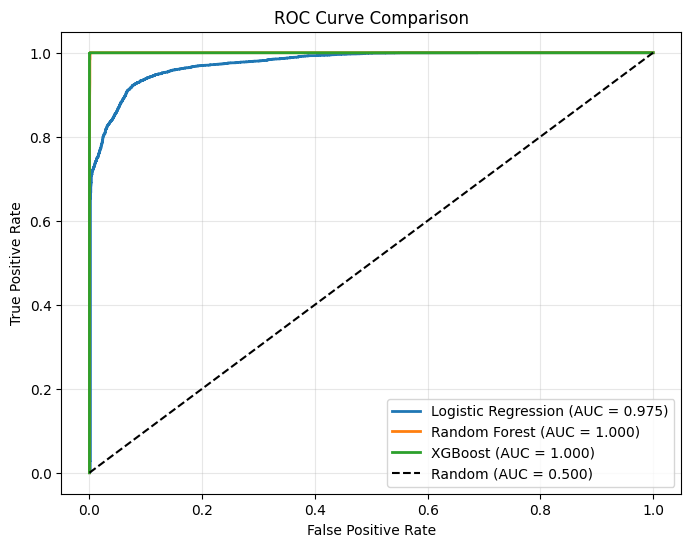

In [53]:

plt.figure(figsize=(8, 6))

# Loop through trained models 
for name, (model, needs_scale) in models.items():
    Xte = x_test_scaled if needs_scale else x_test
    y_proba = trained[name].predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\Confusion_matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**ROC Curve — Observations:**
- XGBoost and RF both meet at  top-left corner with AUC of 1.000 and 0.9999 — they maintain near-perfect true positive rate across every possible false positive threshold.
- LR's curve bends away at high sensitivity — pushing for full recall with LR comes at the cost of a noticeably higher false positive rate, unlike tree models that hold the corner.

Confusion Matrix Comparison

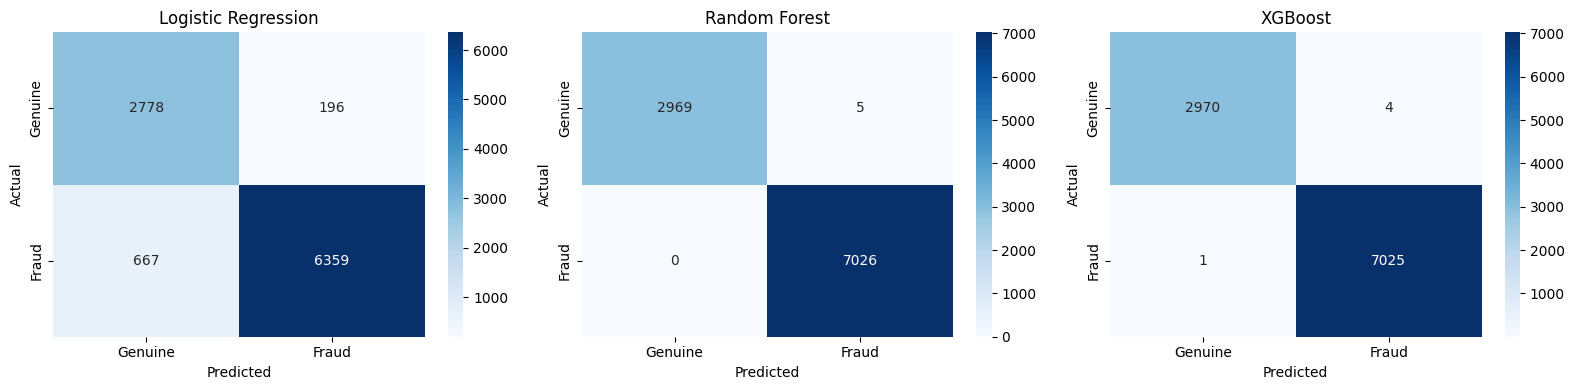

In [54]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (model, needs_scale)) in zip(axes, models.items()):
    Xte = x_test_scaled if needs_scale else x_test
    y_pred = trained[name].predict(Xte)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Genuine', 'Fraud'],
                yticklabels=['Genuine', 'Fraud'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\confusion_matrix.png', dpi = 300, bbox_inches = 'tight' )
plt.show()

**Confusion Matrix — Observations:**
- LR's matrix shows heavy off-diagonal mass — 196 false positives and 667 false negatives, meaning it harasses 196 genuine customers while letting 667 fraudulent orders through unchecked.
- RF's matrix is nearly diagonal — zero false negatives, 5 false positives; it caught every single fraud case in the 10K test set.
- XGBoost's matrix is nearly identical to RF's — 4 FP and 1 FN, one missed fraud vs RF's zero but also one fewer unnecessary flag on a genuine customer.

FP/FN Cost Code

In [55]:

# Business cost assumptions 
COST_FN = 5000   
COST_FP = 1000   

print(f"{'Model':<22}{'FP':>6}{'FN':>6}{'Total Cost':>14}")
for name, (model, needs_scale) in models.items():
    Xte = x_test_scaled if needs_scale else x_test
    cm = confusion_matrix(y_test, trained[name].predict(Xte))
    fp, fn = cm[0, 1], cm[1, 0]
    total = fp * COST_FP + fn * COST_FN
    print(f"{name:<22}{fp:>6}{fn:>6}{total:>14,}")

Model                     FP    FN    Total Cost
Logistic Regression      196   667     3,531,000
Random Forest              5     0         5,000
XGBoost                    4     1         9,000


**FP/FN Cost — Observations:**
- LR's 3.53M total is 99.7% driven by false negatives — 667 missed frauds each sum to 3.335M, and the 196 false alarms are almost a rounding error by comparison.
- RF at 5K is technically cheapest (zero missed frauds, just 5 false flags), but XGBoost at 9K trades 4K extra for marginally better probability calibration and ROC-AUC.
- The cost gap between LR and tree models is 390× on the same 10K test set — this framing makes the model choice far clearer than any accuracy number alone.

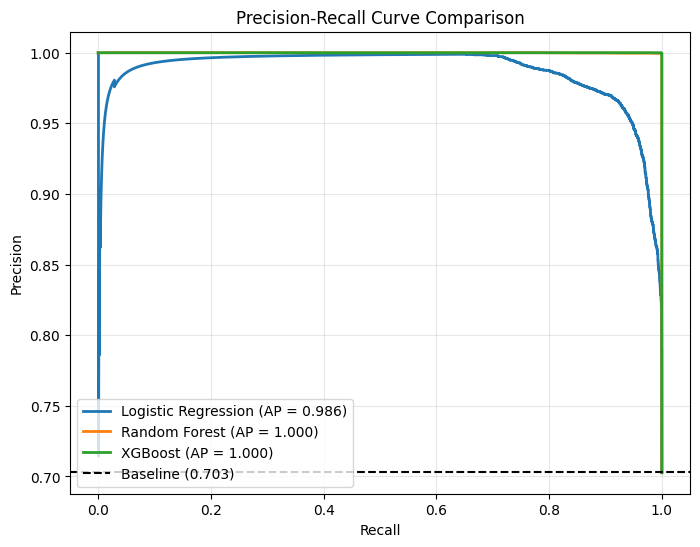

In [56]:


plt.figure(figsize=(8, 6))

for name, (model, needs_scale) in models.items():
    Xte = x_test_scaled if needs_scale else x_test
    y_proba = trained[name].predict_proba(Xte)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP = {ap:.3f})', linewidth=2)

# Baseline = fraud proportion (0.703)
plt.axhline(0.703, color='k', ls='--', label='Baseline (0.703)')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.savefig(r'D:\projects\commerce dataset\E-commerce\reports\Precision_Recall_Curve.png', dpi = 300, bbox_inches = 'tight')
plt.show()


**Precision-Recall Curve — Observations:**
- XGBoost and RF both plot near the top-right corner with AP of 1.000 and 0.9999 — precision stays at 1.0 almost all the way to maximum recall, meaning threshold tuning barely matters for either.
- LR's curve drops off past ~95% recall — chasing full coverage with LR means accepting noticeably more false alarms, a trade-off tree models don't have to make.
- All three models clear the 0.703 baseline (fraud prevalence) by a large margin — even LR at AP=0.986 shows the feature set is genuinely predictive, not just riding the class imbalance.

## Saving Best Model(XGBOOST)

In [57]:
# saving best model  
best_model = trained['XGBoost']
joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(x.columns), "feature_columns.pkl")

print("Model, scaler, feature columns saved")

Model, scaler, feature columns saved


SHAP

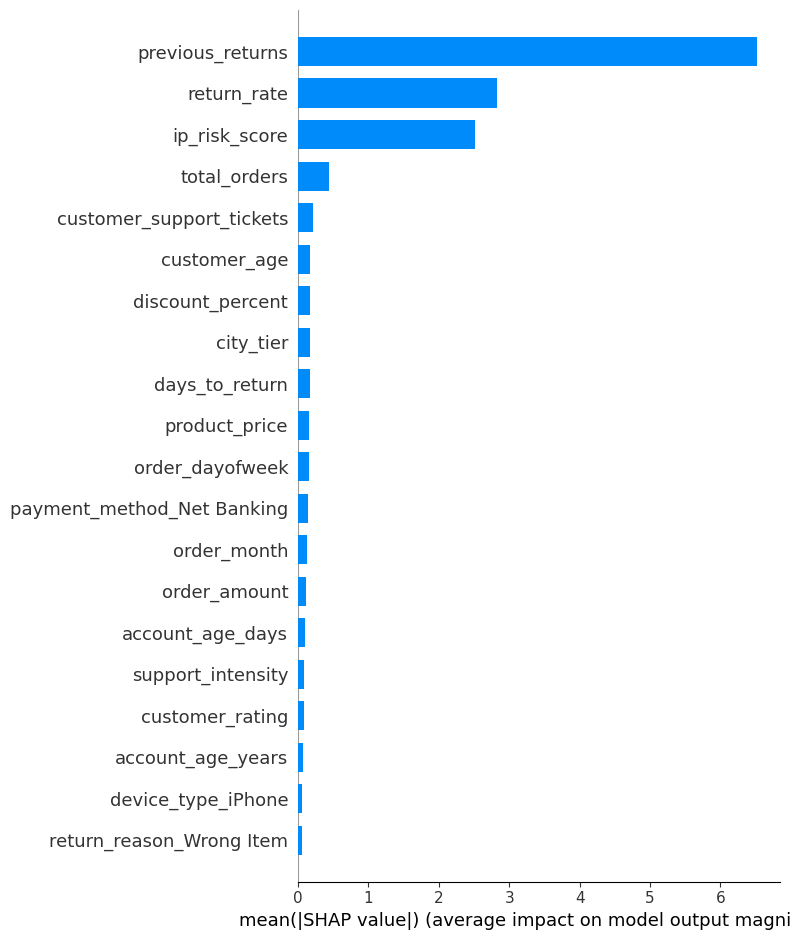

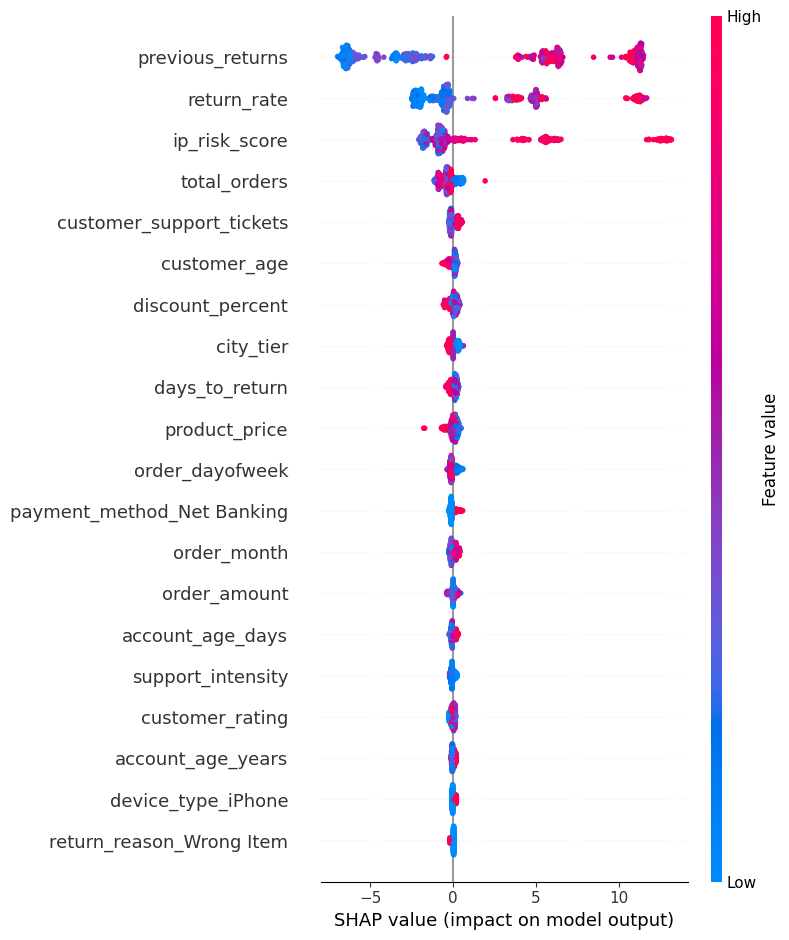

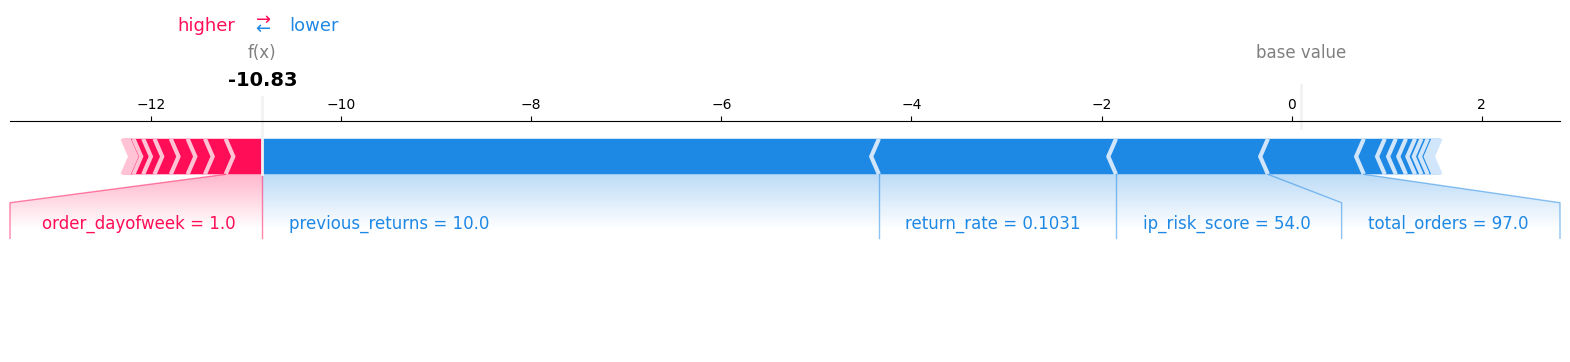

In [ ]:
explainer = shap.TreeExplainer(best_model)

x_sample = x_test.sample(500, random_state = 42)
shap_values = explainer.shap_values(x_sample)

#Global ;  SUmmary plot
shap.summary_plot(shap_values, x_sample, plot_type = 'bar')

#Global ; Beeswarn(Shows direction)
shap.summary_plot(shap_values, x_sample)

#Local 
shap.force_plot(explainer.expected_value, shap_values[0], x_sample.iloc[0], matplotlib = True)




- return_rate has the highest mean absolute SHAP value by a wide margin — it drives more predictions and in a consistent direction (high rate → fraud) than any other feature.
- ip_risk_score ranks second but with a wider SHAP spread in the beeswarm — it contributes heavily for some customers and barely at all for others, making it a context-dependent signal.
- Demographic features (gender, device_type, city_tier) cluster near zero in both the bar and beeswarm plots — the model learned to ignore them entirely, matching the EDA finding that they carry no discriminatory signal.
- The local force plot shows exactly which features pushed a specific customer's prediction toward or away from fraud — this per-decision explainability is what makes the model usable for fraud operations teams, not just model validation.